In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Preparation
dataset = 'pilot' # TUS, joystick, speakup, africa

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/190526/raw'
    unique_subject_ids = [2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/{dataset}/behavioural/speed-accuracy_trade-off'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset)

# Invert objectively_correct score
combined_results_dataframe['objectively_incorrect_boolean'] = 1 - combined_results_dataframe['objectively_correct_boolean']

# RT in milliseconds
combined_results_dataframe['RT_ms'] = combined_results_dataframe['RT_s'] * 1000

These participants will be excluded: {'sub-011_session-02', 'sub-016_session-04', 'sub-011_session-01', 'sub-011_session-04', 'sub-011_session-03'}



# Inverse efficiency score
IES = subject's average RT on correct trials (ms) / 1 - proportion of errors (0.10 for example).\
The higher the score, the less efficient their behaviour.\
Scores can increase with an increase in error rate and/or an increase in RT.

In [3]:
IES_dataframe_congruency = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency'])
IES_dataframe_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['volatility'])
IES_dataframe_congruency_split = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['valence','most_rewarding_response'])
IES_dataframe_congruency_volatility_split = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['valence', 'most_rewarding_response', 'volatility'])

    subject_id  session   congruency       RT_ms  \
0            5        2    congruent  636.118012   
1            5        2  incongruent  663.981250   
2            5        3    congruent  672.158824   
3            5        3  incongruent  690.772727   
4            5        4    congruent  619.135484   
5            5        4  incongruent  626.127168   
6           10        2    congruent  646.654762   
7           10        2  incongruent  700.064935   
8           10        3    congruent  659.098837   
9           10        3  incongruent  669.473054   
10          10        4    congruent  643.537572   
11          10        4  incongruent  656.625698   
12          14        2    congruent  638.269737   
13          14        2  incongruent  588.351351   
14          14        3    congruent  644.579710   
15          14        3  incongruent  584.300000   
16          14        4    congruent  664.270115   
17          14        4  incongruent  671.048193   
18          

## Plot the Inverse Efficiency Score

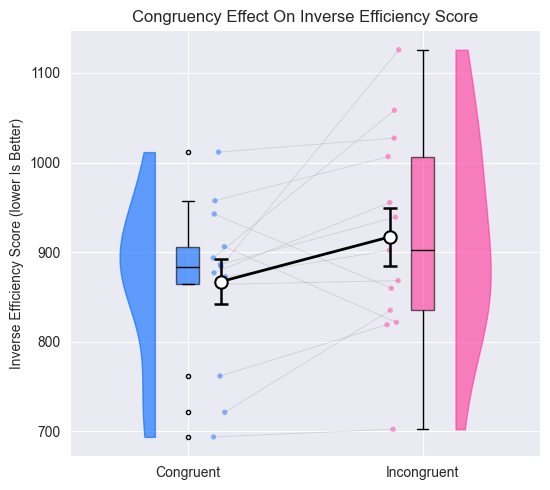

In [4]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    IES_dataframe_congruency
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent', 'incongruent'],
    labels=['congruent', 'incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='congruency effect on inverse efficiency score'
);

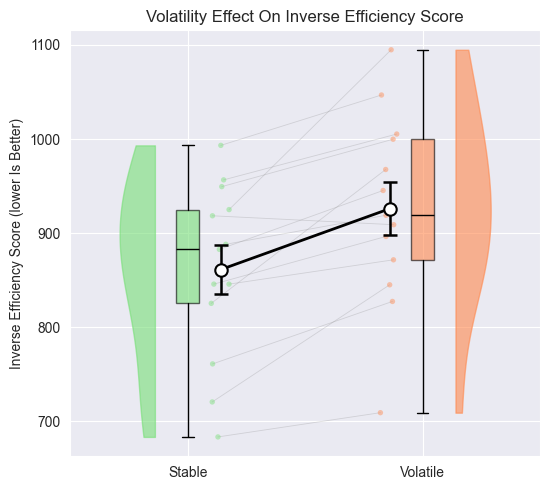

In [5]:
if dataset!='africa':
    # Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        IES_dataframe_volatility
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable', 'volatile'],
        labels=['stable', 'volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='volatility effect on inverse efficiency score',
        colours=['#77DF77', '#FF884D']
    );

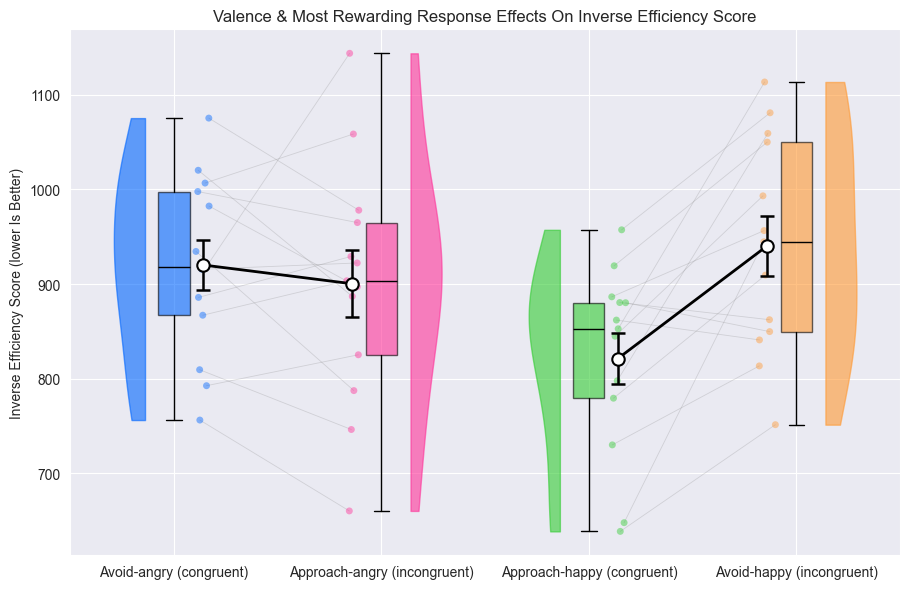

In [6]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        IES_dataframe_congruency_split
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='valence & most rewarding response effects on inverse efficiency score'
    );

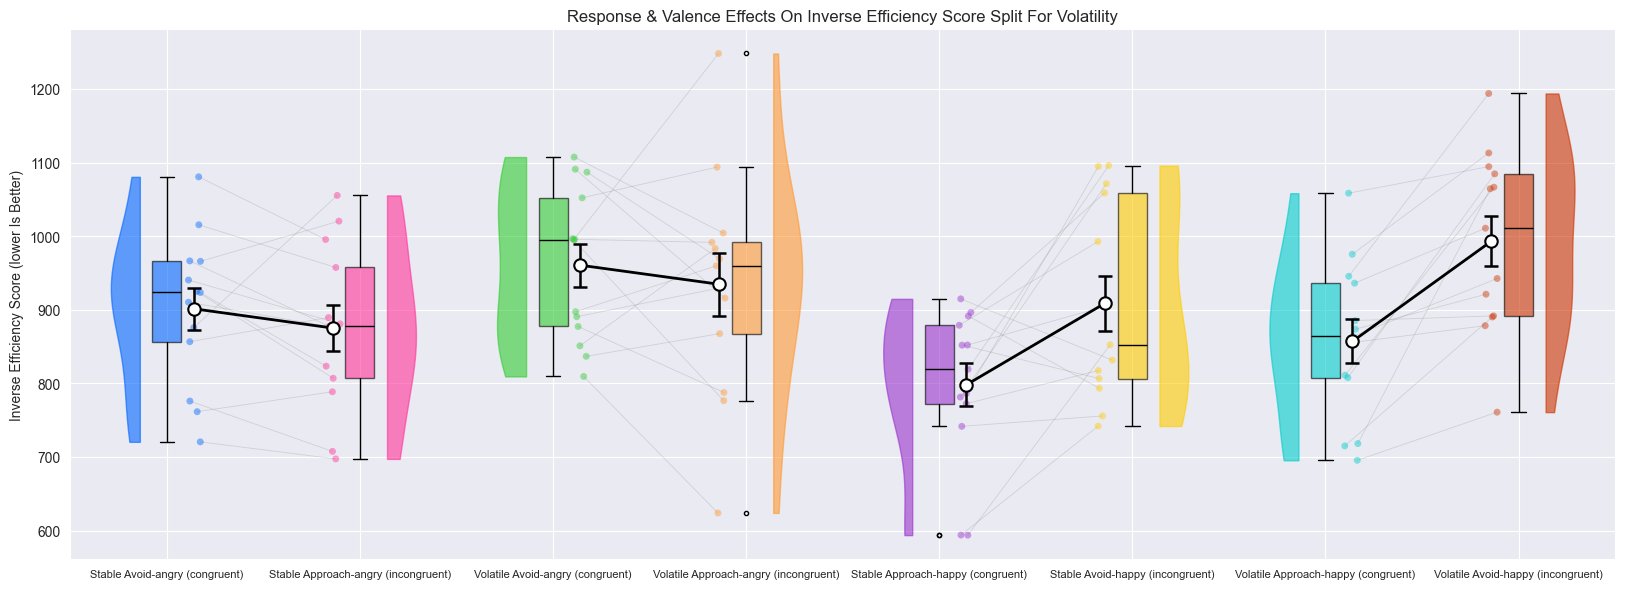

In [7]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        IES_dataframe_congruency_volatility_split
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='response & valence effects on inverse efficiency score split for volatility'
    );

# BIS
Balanced Integration Score = z(PC) − z(RT), with z-scores computed across the entire sample of cells (Liesefeld & Janczyk, 2019)

In [8]:
BIS_dataframe_congruency = utils.analysis_functions.calculate_BIS(combined_results_dataframe, ['congruency'])
BIS_dataframe_volatility = utils.analysis_functions.calculate_BIS(combined_results_dataframe, ['volatility'])
BIS_dataframe_congruency_split = utils.analysis_functions.calculate_BIS(combined_results_dataframe, ['valence','most_rewarding_response'])
BIS_dataframe_congruency_volatility_split = utils.analysis_functions.calculate_BIS(combined_results_dataframe, ['valence', 'most_rewarding_response', 'volatility'])

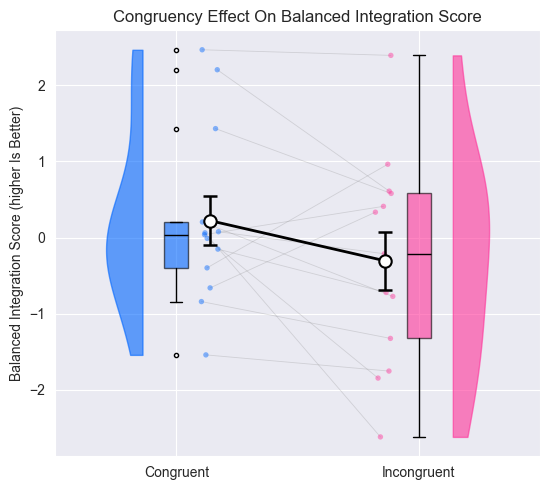

In [9]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    BIS_dataframe_congruency
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='BIS',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent', 'incongruent'],
    labels=['congruent', 'incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='balanced integration score (higher is better)',
    plot_name='congruency effect on balanced integration score'
);

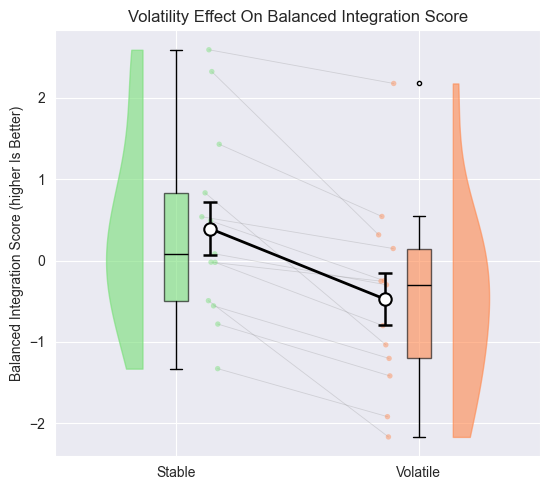

In [10]:
if dataset!='africa':
    # Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        BIS_dataframe_volatility
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='BIS',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable', 'volatile'],
        labels=['stable', 'volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='balanced integration score (higher is better)',
        plot_name='volatility effect on balanced integration score',
        colours=['#77DF77', '#FF884D']
    );

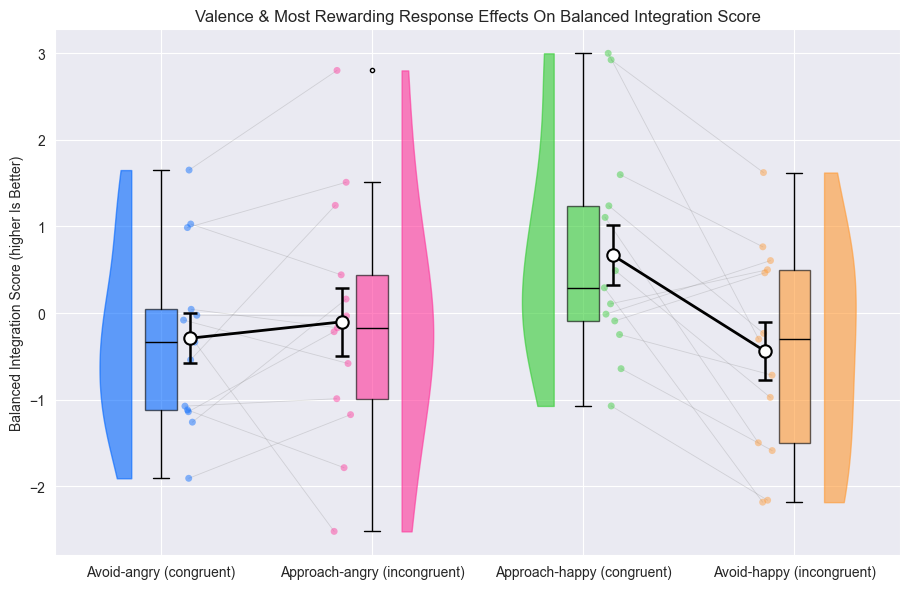

In [11]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        BIS_dataframe_congruency_split
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='BIS',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='balanced integration score (higher is better)',
        plot_name='valence & most rewarding response effects on balanced integration score'
    );

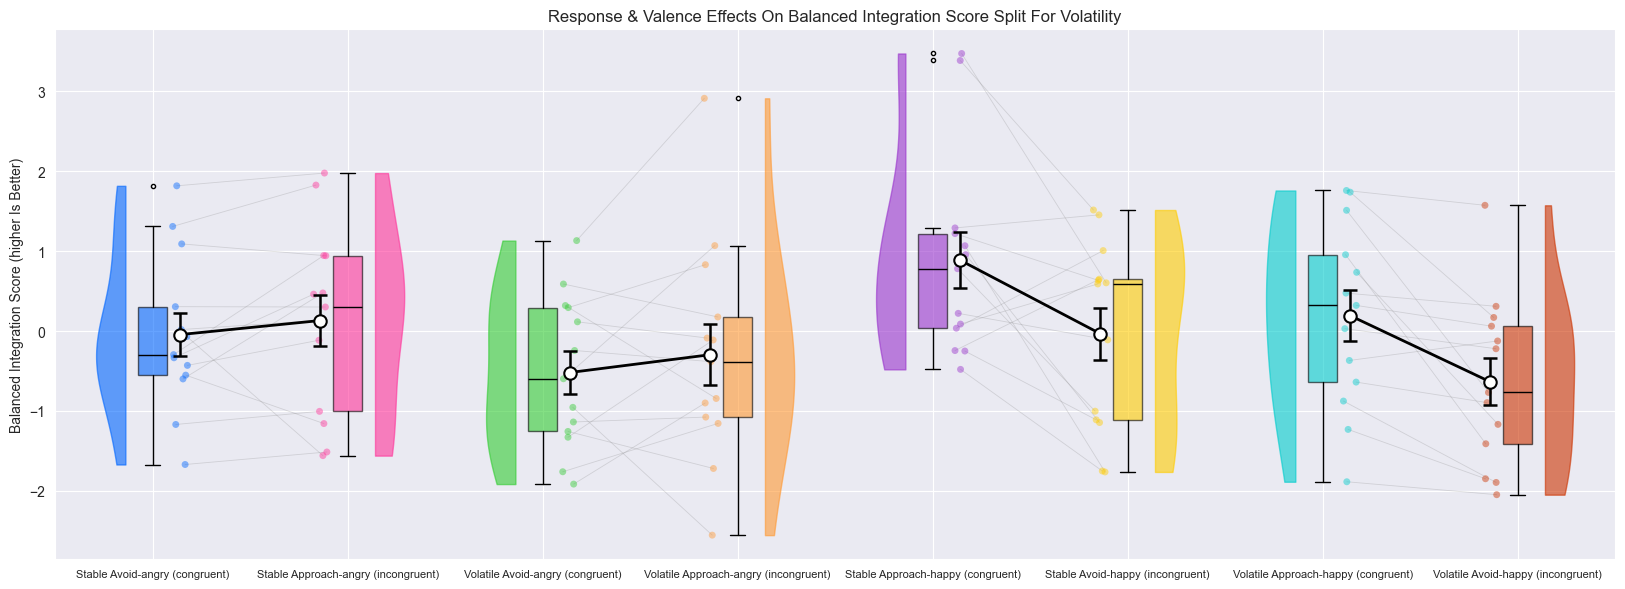

In [12]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        BIS_dataframe_congruency_volatility_split
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='BIS',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='balanced integration score (higher is better)',
        plot_name='response & valence effects on balanced integration score split for volatility'
    );

# Plot the relation between speed and accuracy
Quantile probability function

In [13]:
quadratic_trend = False

In [14]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

    subject_id  session   congruency  mean_reaction_time  mean_performance
0            5        2    congruent          647.278539           0.73516
1            5        2  incongruent          669.265766          0.720721
2            5        3    congruent          675.909502          0.769231
3            5        3  incongruent          696.100917          0.706422
4            5        4    congruent          617.168182          0.704545
5            5        4  incongruent          621.856502          0.775785
6           10        2    congruent          665.765217          0.730435
7           10        2  incongruent          694.535545          0.729858
8           10        3    congruent          676.534783          0.747826
9           10        3  incongruent          666.545024          0.791469
10          10        4    congruent          657.301802          0.779279
11          10        4  incongruent          661.339450          0.821101
12          14        2  

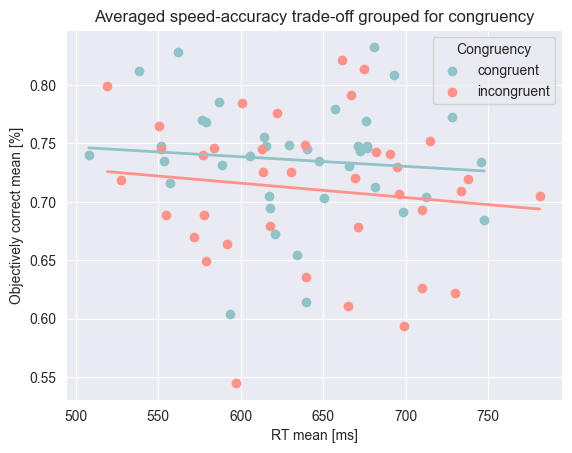

In [15]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [16]:
if dataset!='africa':
    # suppose your original DataFrame is called df
    summary = (
        combined_results_dataframe
        .groupby(['subject_id', 'session', 'volatility'])
        .agg(
            mean_reaction_time=('RT_ms', 'mean'),
            mean_performance=('objectively_correct_boolean', 'mean')
        )
        .reset_index()
    )

    print(summary)

    subject_id  session volatility  mean_reaction_time  mean_performance
0            5        2     stable          657.943966          0.831897
1            5        2   volatile          658.794258           0.61244
2            5        3     stable          681.309013          0.759657
3            5        3   volatile          691.169903          0.713592
4            5        4     stable          624.315068          0.789954
5            5        4   volatile          614.848214          0.691964
6           10        2     stable          681.457399           0.70852
7           10        2   volatile          677.559633          0.752294
8           10        3     stable          675.108108          0.788288
9           10        3   volatile          668.356164          0.748858
10          10        4     stable          663.941176          0.878151
11          10        4   volatile          653.836634          0.707921
12          14        2     stable          590.239

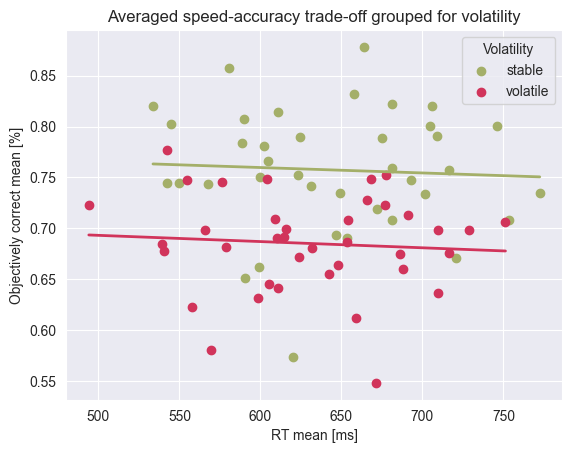

In [17]:
if dataset!='africa':
    x_col = 'mean_reaction_time'
    y_col = 'mean_performance'
    group_col = 'volatility'

    # Define colours for each group
    colour_map = {
        'stable':   '#A4AF69',
        'volatile': '#D1345B',
    }

    fig, ax = plt.subplots()

    for cong, group in summary.groupby(group_col):
        x = group[x_col].values
        y = group[y_col].values
        col = colour_map.get(cong, 'gray')

        # Only the scatter gets a legend label
        ax.scatter(x, y, color=col, label=cong)

        # Fit a trendline
        if quadratic_trend:
            a, b, c = np.polyfit(x, y, deg=2)
            x_smooth = np.linspace(x.min(), x.max(), 200)
            y_smooth = a*x_smooth**2 + b*x_smooth + c

            ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
        else:
            m, c = np.polyfit(x, y, deg=1)
            x_line = np.array([x.min(), x.max()])
            y_line = m*x_line + c

            ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

    ax.set_xlabel('RT mean [ms]')
    ax.set_ylabel('Objectively correct mean [%]')
    plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
    ax.set_title(plot_name)
    ax.legend(title='Volatility')
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
    plt.show()

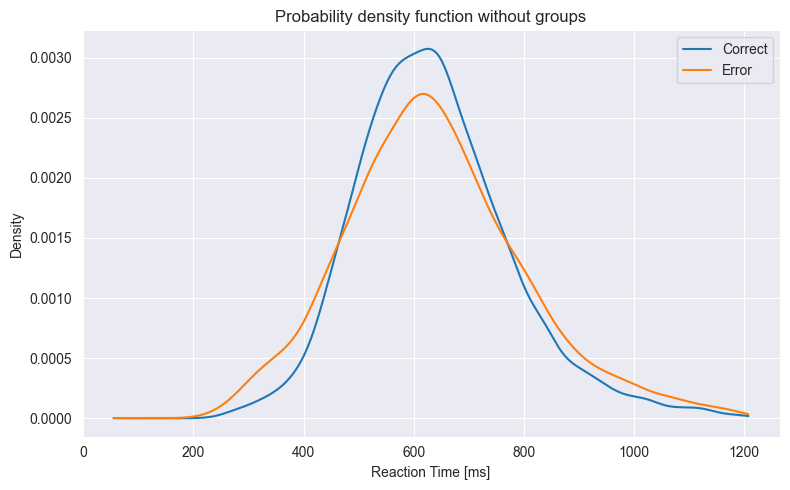

In [18]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_ms']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_ms']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

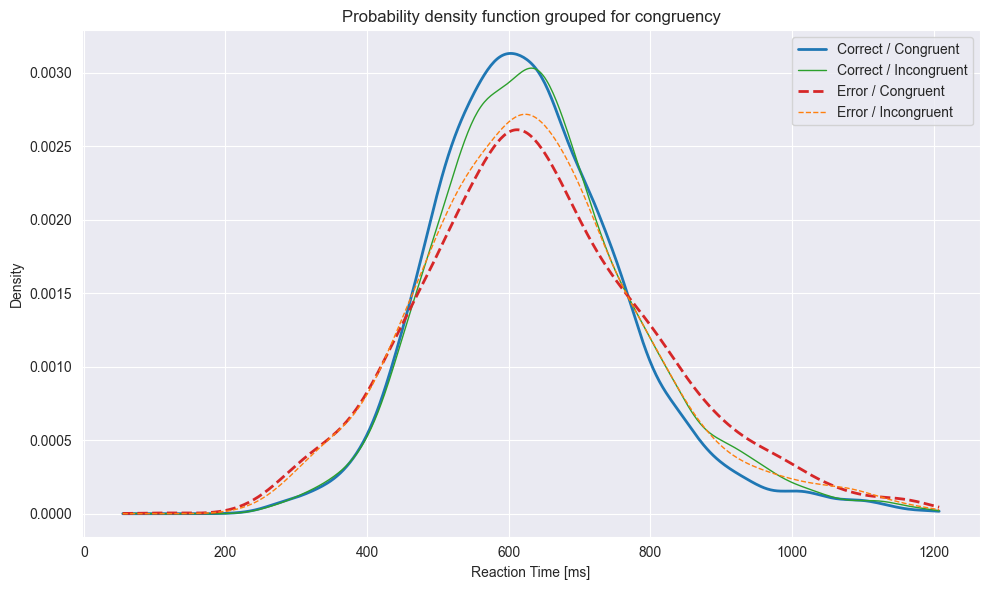

In [19]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

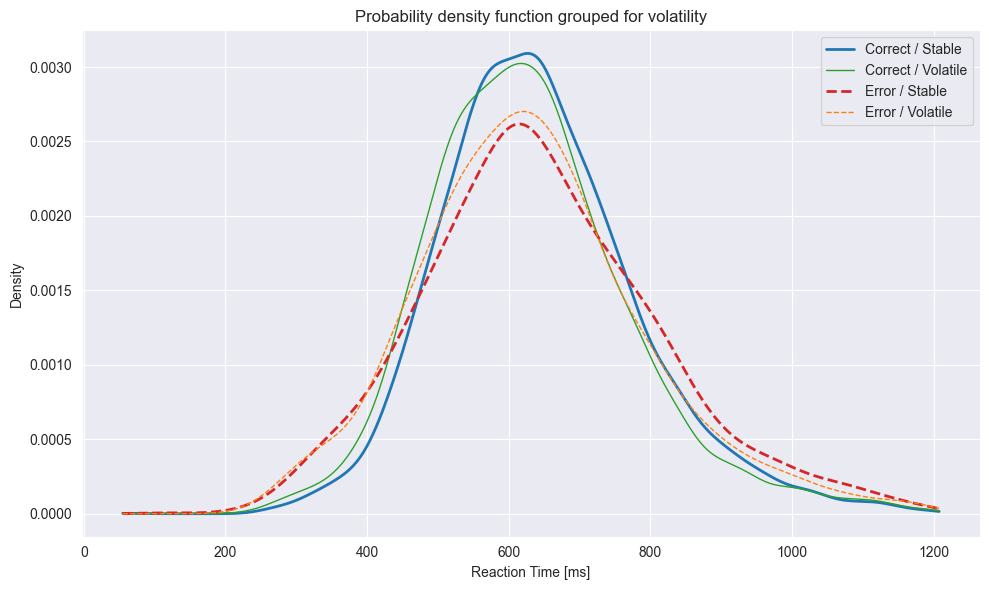

In [20]:
if dataset!='africa':
    # define your two factors
    correctness_levels = {
        1: 'Correct',
        0: 'Error'
    }
    congruency_levels = ['stable', 'volatile']

    # Define your color map for (correctness, congruency)
    color_map = {
        (1, 'stable'):   'tab:blue',
        (1, 'volatile'): 'tab:green',
        (0, 'stable'):   'tab:red',
        (0, 'volatile'): 'tab:orange'
    }

    # Prepare x-axis
    xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
    x_vals = np.linspace(xmin, xmax, 500)

    plt.figure(figsize=(10, 6))

    # Loop through each combination
    for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
        for volatility in ['stable', 'volatile']:
            subset = combined_results_dataframe[
                (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
                (combined_results_dataframe['volatility'] == volatility)
            ]['RT_ms']
            if len(subset) < 2:
                continue

            kde = gaussian_kde(subset)
            label = f"{obj_label} / {volatility.capitalize()}"
            c = color_map[(obj_val, volatility)]

            plt.plot(x_vals, kde(x_vals),
                     label=label,
                     color=c,
                     linestyle='-' if obj_val == 1 else '--',
                     linewidth=2 if volatility == 'stable' else 1)

    # finalize
    plt.xlabel('Reaction Time [ms]')
    plt.ylabel('Density')
    plot_name = 'Probability density function grouped for volatility'
    plt.title(plot_name)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
    plt.show()

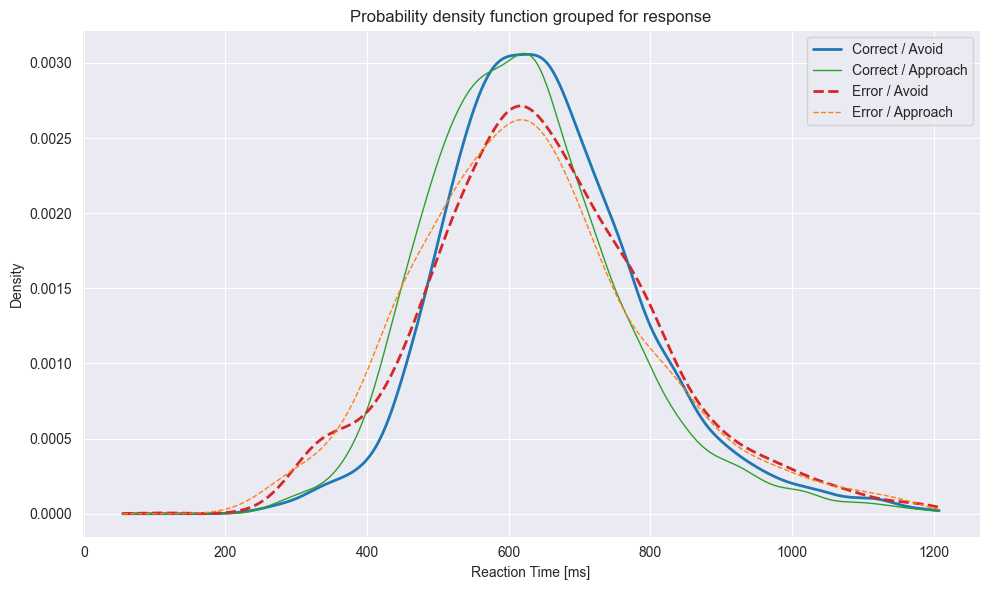

In [21]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['avoid', 'approach']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'avoid'):   'tab:blue',
    (1, 'approach'): 'tab:green',
    (0, 'avoid'):   'tab:red',
    (0, 'approach'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['avoid', 'approach']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'avoid' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()